In [3]:
import pandas as pd

dfhv = pd.read_parquet("home_values.parquet")
dfhv.to_csv("home_values.csv", index = False)
dfhv.shape

(117912, 11)

In [5]:
dfhv.head()

,Region ID,Size Rank,Region,Region Type,State,Home Type,Bedroom Count,Date,Bottom Tier ZHVI (Smoothed) (Seasonally Adjusted),Mid Tier ZHVI (Smoothed) (Seasonally Adjusted),Top Tier ZHVI (Smoothed) (Seasonally Adjusted)
0,3,48,Alaska,4,Alaska,3,0,2000-01-31,NaN,81310.640625,NaN
1,3,48,Alaska,4,Alaska,3,0,2000-02-29,NaN,80419.765625,NaN
2,3,48,Alaska,4,Alaska,3,0,2000-03-31,NaN,80480.453125,NaN
3,3,48,Alaska,4,Alaska,3,0,2000-04-30,NaN,79799.203125,NaN
4,3,48,Alaska,4,Alaska,3,0,2000-05-31,NaN,79666.468750,NaN


In [7]:
dfhv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117912 entries, 0 to 117911
Data columns (total 11 columns):
 #   Column                                             Non-Null Count   Dtype         
---  ------                                             --------------   -----         
 0   Region ID                                          117912 non-null  object        
 1   Size Rank                                          117912 non-null  int32         
 2   Region                                             117912 non-null  object        
 3   Region Type                                        117912 non-null  int64         
 4   State                                              117912 non-null  object        
 5   Home Type                                          117912 non-null  int64         
 6   Bedroom Count                                      117912 non-null  int64         
 7   Date                                               117912 non-null  datetime64[ms]
 8   Bott

In [9]:
print(dfhv.describe())

           Size Rank  Region Type      Home Type  Bedroom Count  \
count  117912.000000     117912.0  117912.000000  117912.000000   
mean       25.431373          4.0       2.625000       3.125000   
min         0.000000          4.0       1.000000       0.000000   
25%        12.000000          4.0       2.750000       1.750000   
50%        25.000000          4.0       3.000000       3.500000   
75%        39.000000          4.0       3.000000       5.000000   
max        51.000000          4.0       3.000000       5.000000   
std        15.146739          0.0       0.695973       1.832868   

                             Date  \
count                      117912   
mean   2012-01-30 02:49:24.705000   
min           2000-01-31 00:00:00   
25%           2006-01-31 00:00:00   
50%           2012-01-31 00:00:00   
75%           2018-01-31 00:00:00   
max           2024-01-31 00:00:00   
std                           NaN   

       Bottom Tier ZHVI (Smoothed) (Seasonally Adjusted)  \
co

In [11]:
dfhv.isnull().sum()

Region ID                                                 0
Size Rank                                                 0
Region                                                    0
Region Type                                               0
State                                                     0
Home Type                                                 0
Bedroom Count                                             0
Date                                                      0
Bottom Tier ZHVI (Smoothed) (Seasonally Adjusted)    103409
Mid Tier ZHVI (Smoothed) (Seasonally Adjusted)         2515
Top Tier ZHVI (Smoothed) (Seasonally Adjusted)       103398
dtype: int64

In [13]:
dfhv_clean = dfhv[dfhv["Mid Tier ZHVI (Smoothed) (Seasonally Adjusted)"].notnull()]
dfhv_clean = dfhv.drop(columns=["Bottom Tier ZHVI (Smoothed) (Seasonally Adjusted)",
    "Top Tier ZHVI (Smoothed) (Seasonally Adjusted)"
])

In [15]:
dfhv = dfhv_clean
dfhv.head()

,Region ID,Size Rank,Region,Region Type,State,Home Type,Bedroom Count,Date,Mid Tier ZHVI (Smoothed) (Seasonally Adjusted)
0,3,48,Alaska,4,Alaska,3,0,2000-01-31,81310.640625
1,3,48,Alaska,4,Alaska,3,0,2000-02-29,80419.765625
2,3,48,Alaska,4,Alaska,3,0,2000-03-31,80480.453125
3,3,48,Alaska,4,Alaska,3,0,2000-04-30,79799.203125
4,3,48,Alaska,4,Alaska,3,0,2000-05-31,79666.468750


In [17]:
print("Region Type:", dfhv["Region Type"].unique())
print("Home Type:", dfhv["Home Type"].unique())

Region Type: [4]
Home Type: [3 2 1]


In [19]:
dfhv['Date'] = pd.to_datetime(dfhv['Date'])
print("Date range:", dfhv['Date'].min(), "to", dfhv['Date'].max())

Date range: 2000-01-31 00:00:00 to 2024-01-31 00:00:00


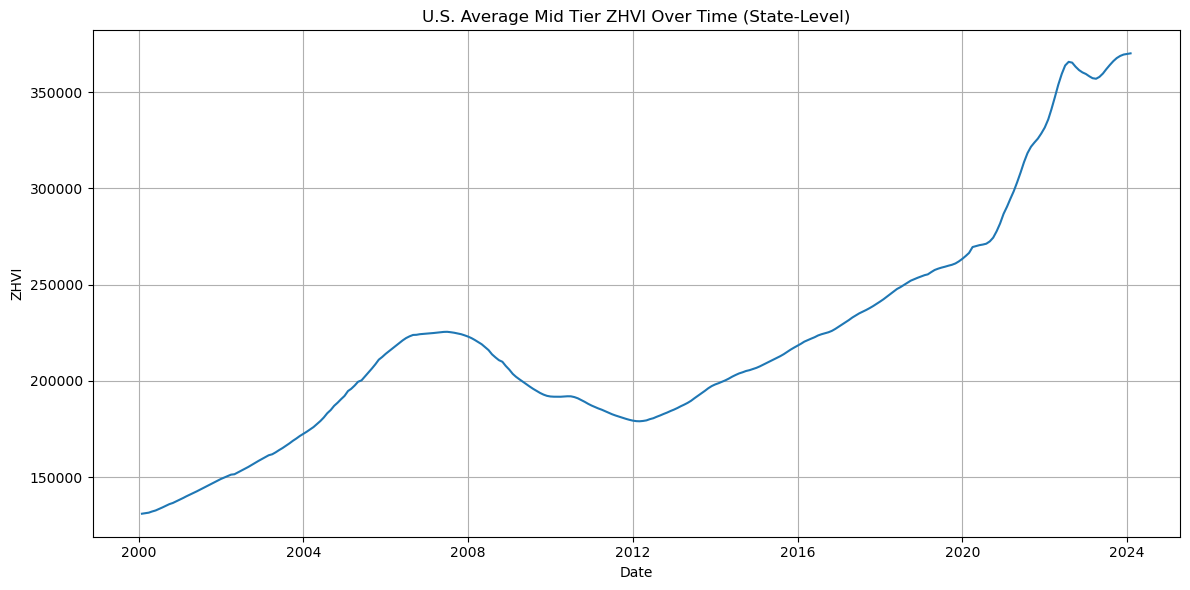

In [23]:
from matplotlib import pyplot as plt
us_avg = dfhv.groupby('Date')['Mid Tier ZHVI (Smoothed) (Seasonally Adjusted)'].mean()

plt.figure(figsize=(12,6))
plt.plot(us_avg.index, us_avg.values)
plt.title('U.S. Average Mid Tier ZHVI Over Time (State-Level)')
plt.xlabel('Date')
plt.ylabel('ZHVI')
plt.grid(True)
plt.tight_layout()
plt.show()

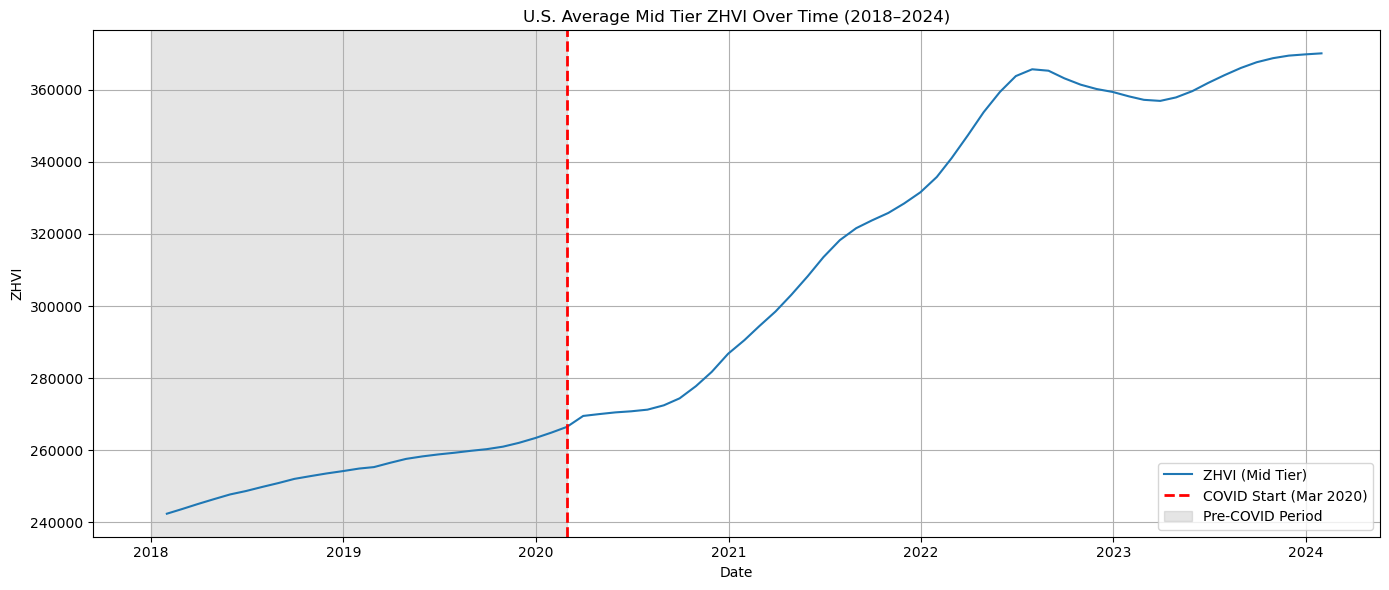

In [63]:
us_avg_filtered = us_avg[us_avg.index >= '2018-01-01']

# Plot with COVID marker
plt.figure(figsize=(14, 6))
plt.plot(us_avg_filtered.index, us_avg_filtered.values, label='ZHVI (Mid Tier)')

# Add COVID start line
covid_start = pd.to_datetime('2020-03-01')
plt.axvline(covid_start, color='red', linestyle='--', linewidth=2, label='COVID Start (Mar 2020)')

plt.axvspan(pd.to_datetime('2018-01-01'), covid_start, color='gray', alpha=0.2, label='Pre-COVID Period')

plt.title('U.S. Average Mid Tier ZHVI Over Time (2018–2024)')
plt.xlabel('Date')
plt.ylabel('ZHVI')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

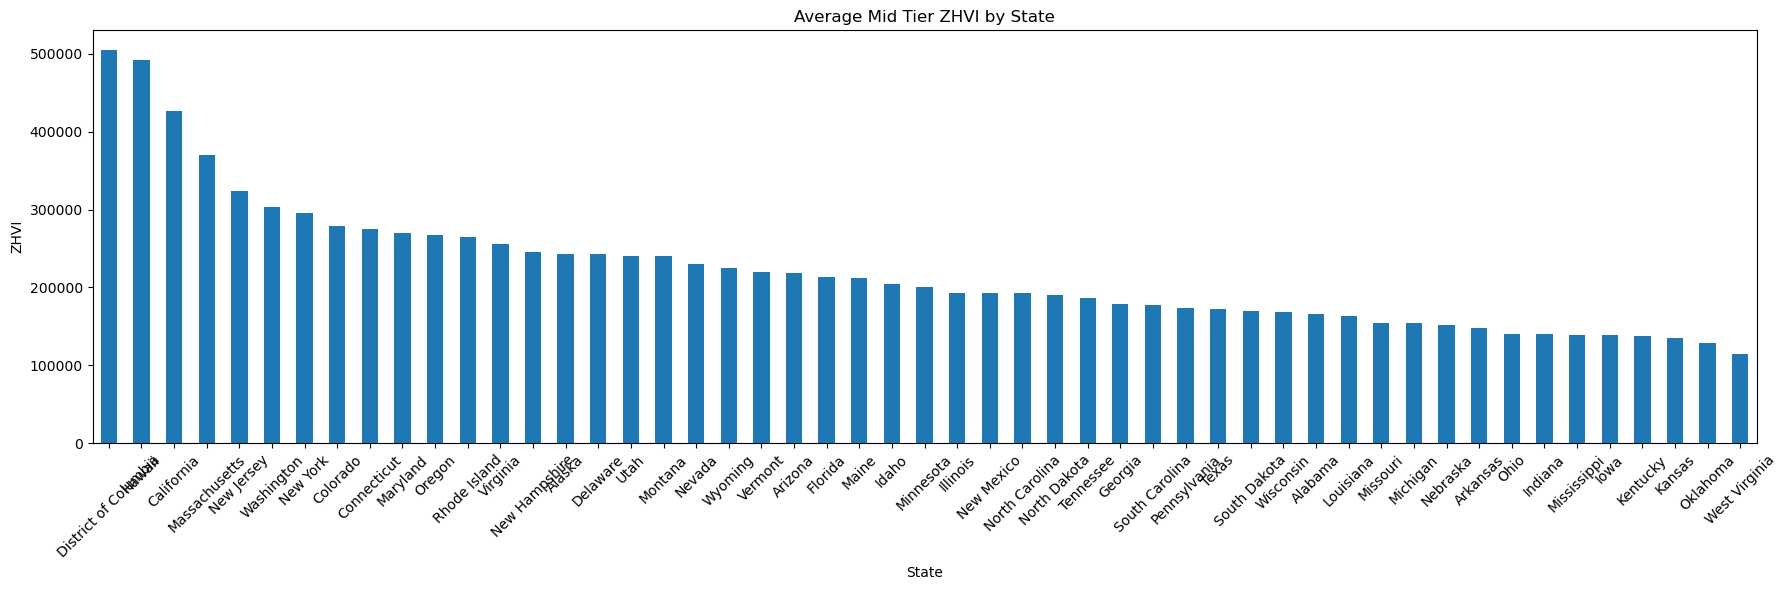

In [31]:
state_avg = dfhv.groupby('State')['Mid Tier ZHVI (Smoothed) (Seasonally Adjusted)'].mean().sort_values(ascending=False)

plt.figure(figsize=(18,6))
state_avg.plot(kind='bar')
plt.title('Average Mid Tier ZHVI by State')
plt.ylabel('ZHVI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

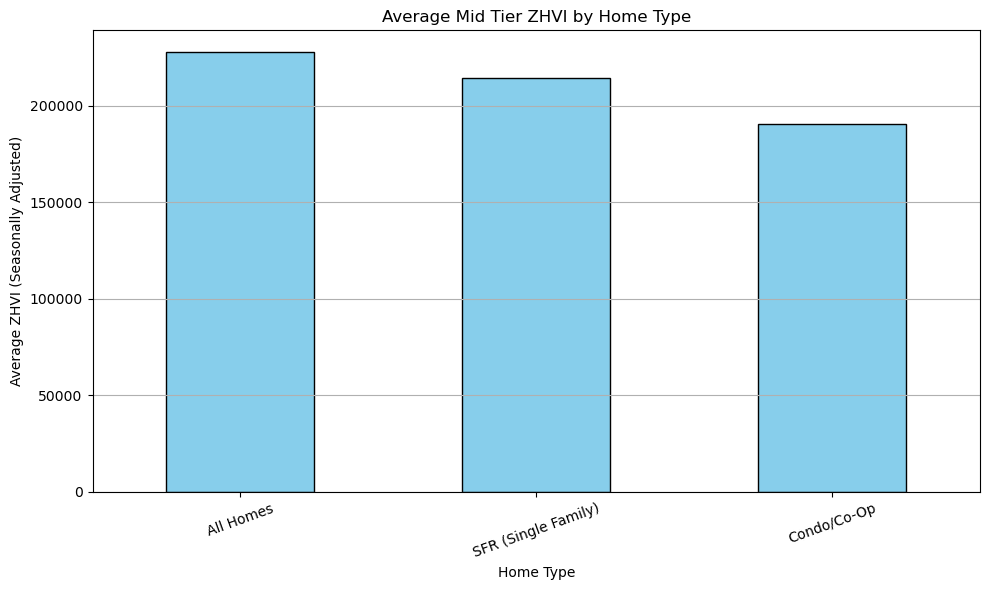

In [35]:
home_type_labels = {
    0: 'Multifamily',
    1: 'Condo/Co-Op',
    2: 'SFR (Single Family)',
    3: 'All Homes',
    4: 'All Homes + Multifamily'
}
dfhv['Home Type Label'] = dfhv['Home Type'].map(home_type_labels)

home_type_avg = dfhv.groupby('Home Type Label')['Mid Tier ZHVI (Smoothed) (Seasonally Adjusted)'].mean().sort_values(ascending=False)


plt.figure(figsize=(10,6))
home_type_avg.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Mid Tier ZHVI by Home Type')
plt.xlabel('Home Type')
plt.ylabel('Average ZHVI (Seasonally Adjusted)')
plt.xticks(rotation=20)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

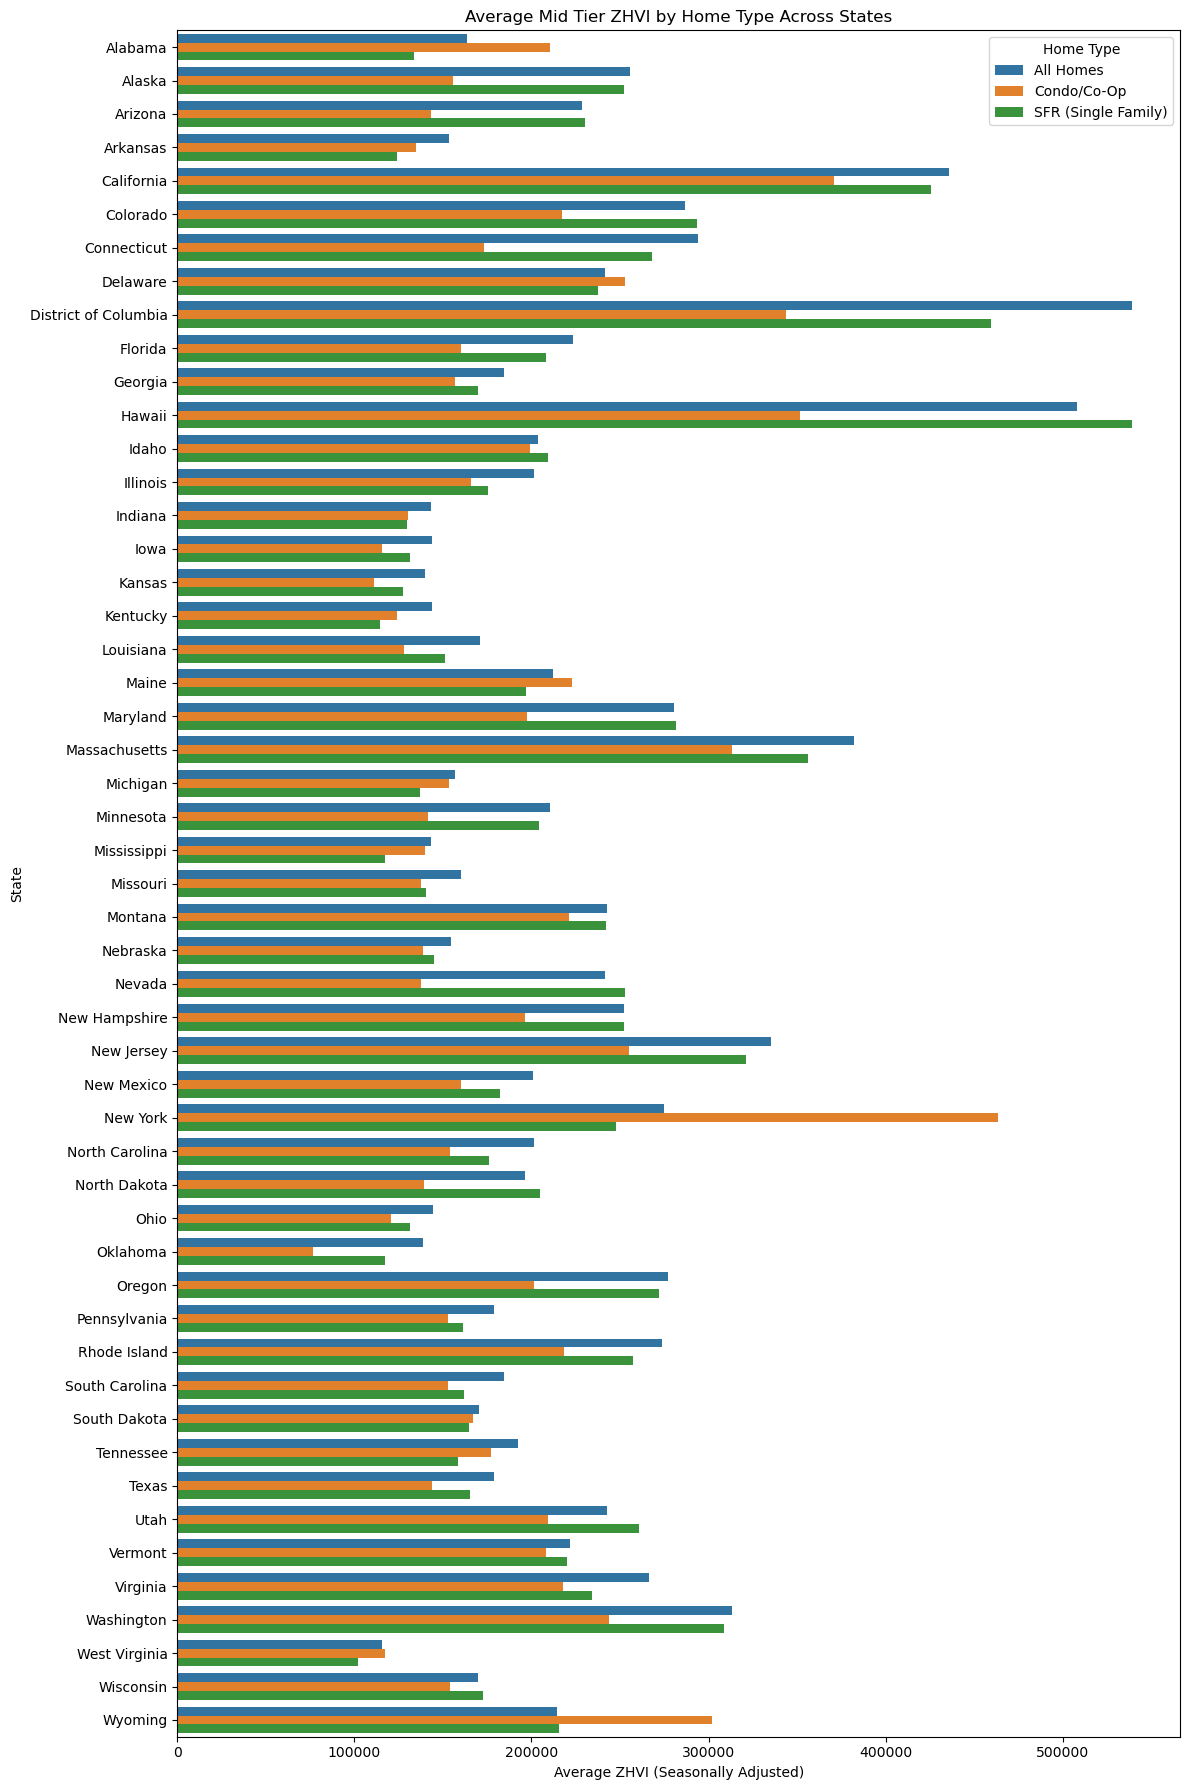

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

home_type_labels = {
    0: 'Multifamily',
    1: 'Condo/Co-Op',
    2: 'SFR (Single Family)',
    3: 'All Homes',
    4: 'All Homes + Multifamily'
}
dfhv['Home Type Label'] = dfhv['Home Type'].map(home_type_labels)

state_home_avg = dfhv.groupby(['State', 'Home Type Label'])['Mid Tier ZHVI (Smoothed) (Seasonally Adjusted)'].mean().reset_index()

plt.figure(figsize=(12, 18))
sns.barplot(data=state_home_avg, y='State', x='Mid Tier ZHVI (Smoothed) (Seasonally Adjusted)', hue='Home Type Label')

plt.title('Average Mid Tier ZHVI by Home Type Across States')
plt.xlabel('Average ZHVI (Seasonally Adjusted)')
plt.ylabel('State')
plt.legend(title='Home Type')
plt.tight_layout()
plt.show()

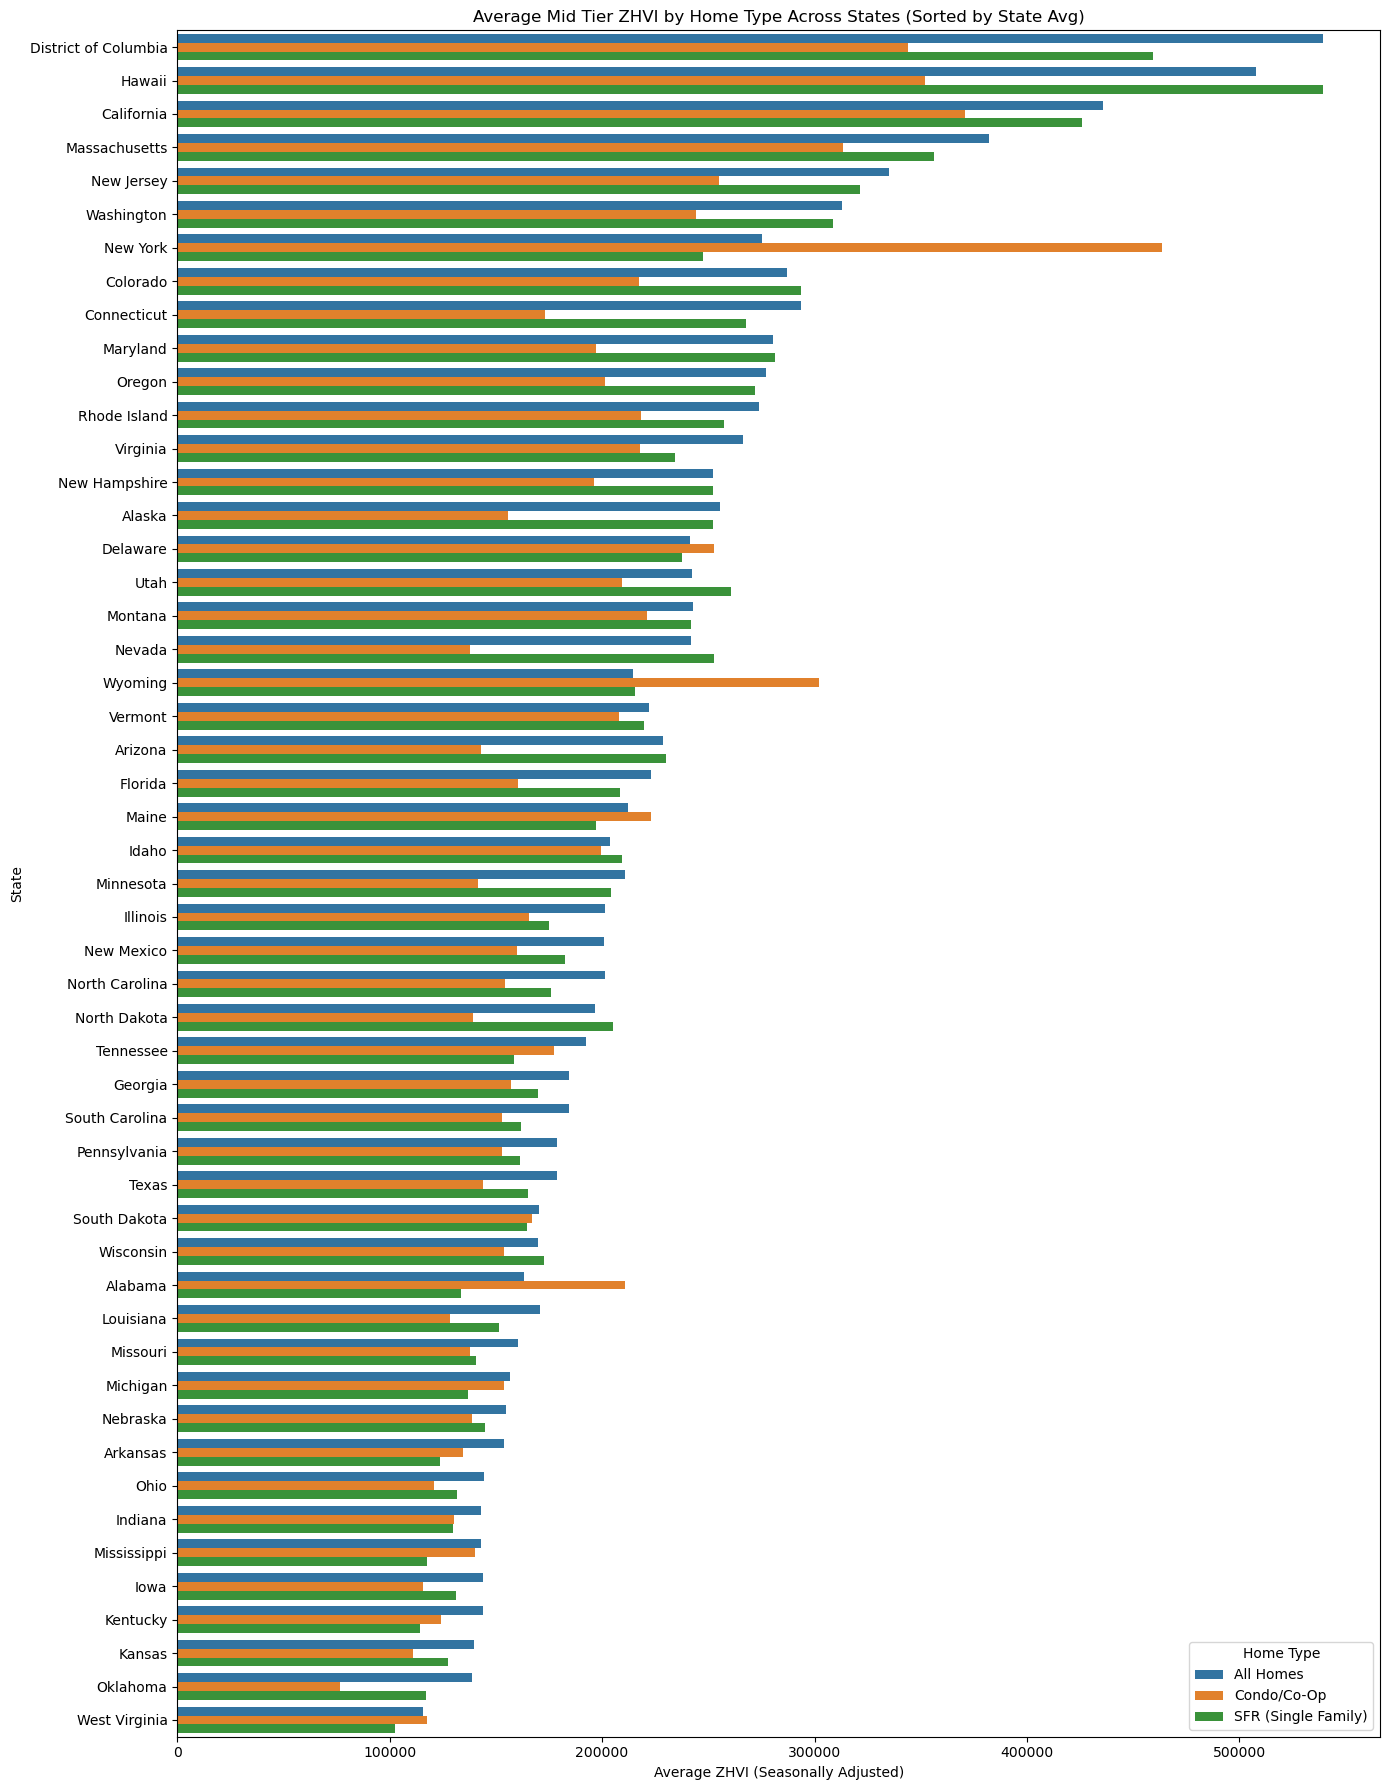

In [59]:
state_order = dfhv.groupby('State')['Mid Tier ZHVI (Smoothed) (Seasonally Adjusted)'].mean().sort_values(ascending=False).index


plt.figure(figsize=(14, 18))
sns.barplot(
    data=state_home_avg,
    y='State',
    x='Mid Tier ZHVI (Smoothed) (Seasonally Adjusted)',
    hue='Home Type Label',
    order=state_order  
)
plt.title('Average Mid Tier ZHVI by Home Type Across States (Sorted by State Avg)')
plt.xlabel('Average ZHVI (Seasonally Adjusted)')
plt.ylabel('State')
plt.legend(title='Home Type')
plt.tight_layout()
plt.show()